In [37]:
import torch
torch.set_grad_enabled(False)
import sys
import time
import random
import csv
import numpy as np
import threading

import scipy.io
from scipy.io import loadmat

import pickle

from tqdm import tqdm
from tqdm import notebook

import matplotlib
import matplotlib.pyplot as plt

import importlib
from gaussian_processes.Spatial_GP_repo import utils as GP_utils

import sys
sys.path.insert(0, '/home/idv-eqs8-pza/IDV_code/ClosedLoopProject')
from gaussian_processes.Spatial_GP_repo import utility as GP_utility
from gaussian_processes.Spatial_GP_repo.model import GPModel
from gaussian_processes.Spatial_GP_repo import utils as GP_utils

from config import config

from pathlib import Path

import copy
# Enable autoreload
%load_ext autoreload
%autoreload 2
importlib.reload(GP_utils)

# Set seeds for reproducibility
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    torch.cuda.manual_seed_all(0)  # if you are using multi-GPU.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# TORCH_DTYPE = torch.float64 #NB: Basically all of the matrices in Spatial_GP have 1.e-7 added to the diagonal, to be changed if we want to use float64
TORCH_DTYPE = torch.float32

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
torch.set_default_dtype(TORCH_DTYPE)
torch.set_default_device(device)
print(f'Device is: {device}')




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
In GP Utils: Default device: cuda:0
In GP Utils: Default dtype: torch.float32
Device is: cuda:0


### How this works:

We choose initial training points to be considered a random set of images to present to the retina. On this set, the complete GP will be run , to find STA paramaters eps_0: center, beta: width , rho: smoothness

We run the algorithm saving the seed used for picking the training images, so that this set can be changed and different runs with different initial conditions can be averaged.

1. Import the dataset and create a total training set X,R
2. Pick the cell and the initial training points, extracted randomly. These correspond also to the number of inducing points
3. Save the seed so you can keep the initial training set, and the fitted model
3. 


### Parameters of the training

In [29]:
rand_xtilde = True # If True, xtilde (inducing points) are chosen randomly, if False, xtilde is chosen from the first ntilde images

cellid       = 8         # Choose cell
ntrain_start = 500        # Number of first training data points

kernfun      = 'acosker' # Choose kernel function

nEstep       = 15         # Total number of E-steps iterations.
nFparamstep  = 15  
nMstep       = 15         # Total number of M-steps iterations. 
maxiter      = 40         # Iterations of the optimization algorithm comprising M and E steps

ntilde       = ntrain_start

### Import dataset and generate starting dataset

Create starting dataset on which to train with m step with ntilde = ntrain_start

In [ ]:
# ( Had to import with the old " Dataset" class required by pickle, still something from samueles code)

# Load with the hack once 
# import sys
# sys.path.insert(0, '/home/idv-eqs8-pza/IDV_code/ClosedLoopProject/gaussian_processes/Spatial_GP_repo')
# import pickle
# with open('/home/idv-eqs8-pza/IDV_code/Variational_GP/spatial_GP/Data/data2_41mixed_tr28.pkl', 'rb') as f:
#     loaded_data = pickle.load(f)

# # Save as portable .npz
# import numpy as np
# np.savez('data2_41mixed_tr28.npz',
#     images_train=loaded_data.images_train,
#     images_val=loaded_data.images_val,
#     images_test=loaded_data.images_test,
#     responses_train=loaded_data.responses_train,
#     responses_val=loaded_data.responses_val,
#     responses_test=loaded_data.responses_test)

# Then load cleanly forever after:
data = np.load('PNAS_paper_sorted_data.npz')

In [30]:
X_train = torch.tensor(data['images_train'], dtype=TORCH_DTYPE) #shape (2910,108,108,1) where 108 is the number of pixels. 2910 is the amount of training points
X_val   = torch.tensor(data['images_val'], dtype=TORCH_DTYPE)
X_test  = torch.tensor(data['images_test'], dtype=TORCH_DTYPE)  # shape (30,108,108,1) # nimages, npx, npx

R_train = torch.tensor(data['responses_train'], dtype=TORCH_DTYPE) #shape (2910,41) 2910 is the amount of training data, 41 is the number of cells
R_val   = torch.tensor(data['responses_val'], dtype=TORCH_DTYPE)
R_test  = torch.tensor(data['responses_test'], dtype=TORCH_DTYPE) # shape (30,30,42) 30 repetitions, 30 images, 42 cells

# Create the complete dataset
X = torch.cat( (X_train, X_val), axis=0,) #shape (3160,108,108,1)
R = torch.cat( (R_train, R_val), axis=0,)

n_px_side = X.shape[1]  

# Reshape images to 1D vector and choose a cell
X = torch.reshape(X, ( X.shape[0], X.shape[1]*X.shape[2])) 
R = R[:,cellid] # shape (nt,) where nt is the number of trials
R_test = R_test[...,cellid] # shape (30,) 30 repetitions

# Choose a random subset of the data and save the idx
all_idx  = torch.arange(0, X.shape[0])                     # Indices of the whole dataset  
torch.manual_seed(8)
torch.cuda.manual_seed(8)
all_idx_perm  = torch.randperm(all_idx.shape[0])                         # Random permutation of the indices

test_1000_idx = all_idx_perm[-1000:]                                     # These will be the indices of the test set
all_idx_perm  = all_idx_perm[~torch.isin( all_idx_perm, test_1000_idx )] # Remove the test set indices from the permutation
rndm_idx      = all_idx_perm[:ntrain_start]                              # These will be the indices of the initial training. This way ensures not repetitions.


start_idx     = rndm_idx
# start_idx     = rndm_idx.sort()[0]
in_use_idx    = start_idx
xtilde_idx    = in_use_idx
remaining_idx = all_idx_perm[~torch.isin( all_idx_perm, in_use_idx )]
# remaining_idx = all_idx_perm[~torch.isin( all_idx_perm, in_use_idx )].sort()[0]

# Set the starting set
xtilde_start  = X[xtilde_idx,:]                           # In the simplest case the starting points are all inducing points
X_in_use      = X[in_use_idx,:]
X_remaining   = X[remaining_idx,:]
X_test_1000   = X[test_1000_idx,:]

R_remaining   = R[remaining_idx]
R_in_use      = R[in_use_idx]
R_test_1000   = R[test_1000_idx]

# Estimate memory usage
# Calculate memory usage for each tensor
X_memory = X.element_size() * X.nelement()
r_memory = R.element_size() * R.nelement()
# Total memory usage in bytes
total_memory_bytes = X_memory + r_memory
# Convert bytes to megabytes (MB)
total_memory_MB = total_memory_bytes / (1024 ** 2)
print(f'Total dataset memory on GPU: {total_memory_MB:.2f} MB')


Total dataset memory on GPU: 140.62 MB


### Select cell, starting hyperparameters and firing rate parameters

In [31]:
torch.set_grad_enabled(False)
# For details on the hyperparameters choice see one_cell_fit.ipynb
logbetaexpr = GP_utils.fromlogbetasam_to_logbetaexpr( logbetasam=torch.tensor(5.5) )# Logbetaexpr in this code is equal to logbeta in Samuele's code. Samuele's code set logbeta to 5.5
logrhoexpr  = GP_utils.fromlogrhosam_to_logrhoexpr( logrhosam=torch.tensor(5)) 
# logbetaexpr = torch.tensor(4.65)
# logrhoexpr = torch.tensor(4.3)
sigma_0    = torch.tensor(1.0)
Amp        = torch.tensor(1.0) 
eps_0x     = torch.tensor(0.0001)
eps_0y     = torch.tensor(0.0001)
# Hypermarameters, if needed to be set manually
theta = {'sigma_0': sigma_0, 'Amp': Amp, 'eps_0x':eps_0x, 'eps_0y':eps_0y, '-2log2beta': logbetaexpr, '-log2rho2': logrhoexpr,  }

# Set the gradient of the hyperparemters to be updatable 
for key, value in theta.items(): # to exclude a single hyperparemeters from the optimization ( to exclude them all just set nmstep=0 and dont do the M-step)
    # if key == 'Amp':
        # continue
    theta[key] = value.requires_grad_()

# If hyperparameters are set manually:
# theta = prev_theta
hyperparams_tuple = GP_utils.generate_theta( x=X_in_use, r=R_in_use, n_px_side=n_px_side, display_hyper=True, **theta)
# If hyperparameters are set based on the STAs:
# hyperparams_tuple = GP_utils.generate_theta( x=X, r=r, n_px_side=n_px_side, display=True)

A        = torch.tensor(0.01)
logA     = torch.log(A)
# lambda0  = torch.tensor(0.31)
lambda0  = torch.tensor(1.)
f_params = {'logA': logA, 'lambda0':lambda0}
f_params['logA'] = f_params['logA'].requires_grad_() # The optimal lambda0 is given with a fixed A.

fit_parameters = {'ntilde':      ntilde,
                  'maxiter':     maxiter,
                  'nMstep':      nMstep,
                  'nEstep':      nEstep,
                  'nFparamstep': nFparamstep,
                  'kernfun':     kernfun,
                  'cellid':      cellid,
                  'n_px_side':   n_px_side,
                  'in_use_idx':  in_use_idx,     # Used idx for generating xtilde, referred to the whole X dataset
                  'xtilde_idx':  xtilde_idx,     # Used idx for generating the complete set, referred to the whole X dataset
                  'start_idx':   start_idx }     # Indexes used to generate the initial training set, same as the starting xtilde

init_model = {
        'fit_parameters':    fit_parameters,
        'xtilde':            xtilde_start,
        'hyperparams_tuple': hyperparams_tuple,     # Contains also the upper and lower bounds for the hyperparameters
        'f_params':          f_params,
        # 'm':                 torch.zeros( (ntilde) )
        # 'm': torch.ones( (ntilde) )
        #'V': dont initialize V if you want it to be initialized as K_tilde and projected _exactly_ as K_tilde_b for stabilisation
    }

updated sigma_0 to 1.0000
updated Amp to 1.0000
updated eps_0x to 0.0001
updated eps_0y to 0.0001
updated -2log2beta to 4.8069
updated -log2rho2 to 4.3069


### Fit the starting model
And save it needed to start a new active fit

Initial Loss: 985.3834
Loss iter 1: 543.6342
 Mstep of iteration 1
Loss iter 2: 511.9282
 Mstep of iteration 2
Loss iter 3: 504.1972
 Mstep of iteration 3
Loss iter 4: 499.3776
 Mstep of iteration 4
Loss iter 5: 494.7031
 Mstep of iteration 5
Loss iter 6: 490.0569
 Mstep of iteration 6
Loss iter 7: 484.8869
 Mstep of iteration 7
Loss iter 8: 480.3734
 Mstep of iteration 8
Loss iter 9: 475.4869
 Mstep of iteration 9
Loss iter 10: 471.1288
 Mstep of iteration 10
Loss iter 11: 467.4755
 Mstep of iteration 11
Loss iter 12: 464.8292
 Mstep of iteration 12
Loss iter 13: 461.8096
 Mstep of iteration 13
Loss iter 14: 459.5728
 Mstep of iteration 14
Loss iter 15: 458.0570
 Mstep of iteration 15
Loss iter 16: 456.5413
 Mstep of iteration 16
Loss iter 17: 455.0985
 Mstep of iteration 17
Loss iter 18: 454.3220
 Mstep of iteration 18
Loss iter 19: 453.7199
 Mstep of iteration 19
Loss iter 20: 453.2405
 Mstep of iteration 20
Loss iter 21: 452.8705
 Mstep of iteration 21
Loss iter 22: 452.5494
 Mstep

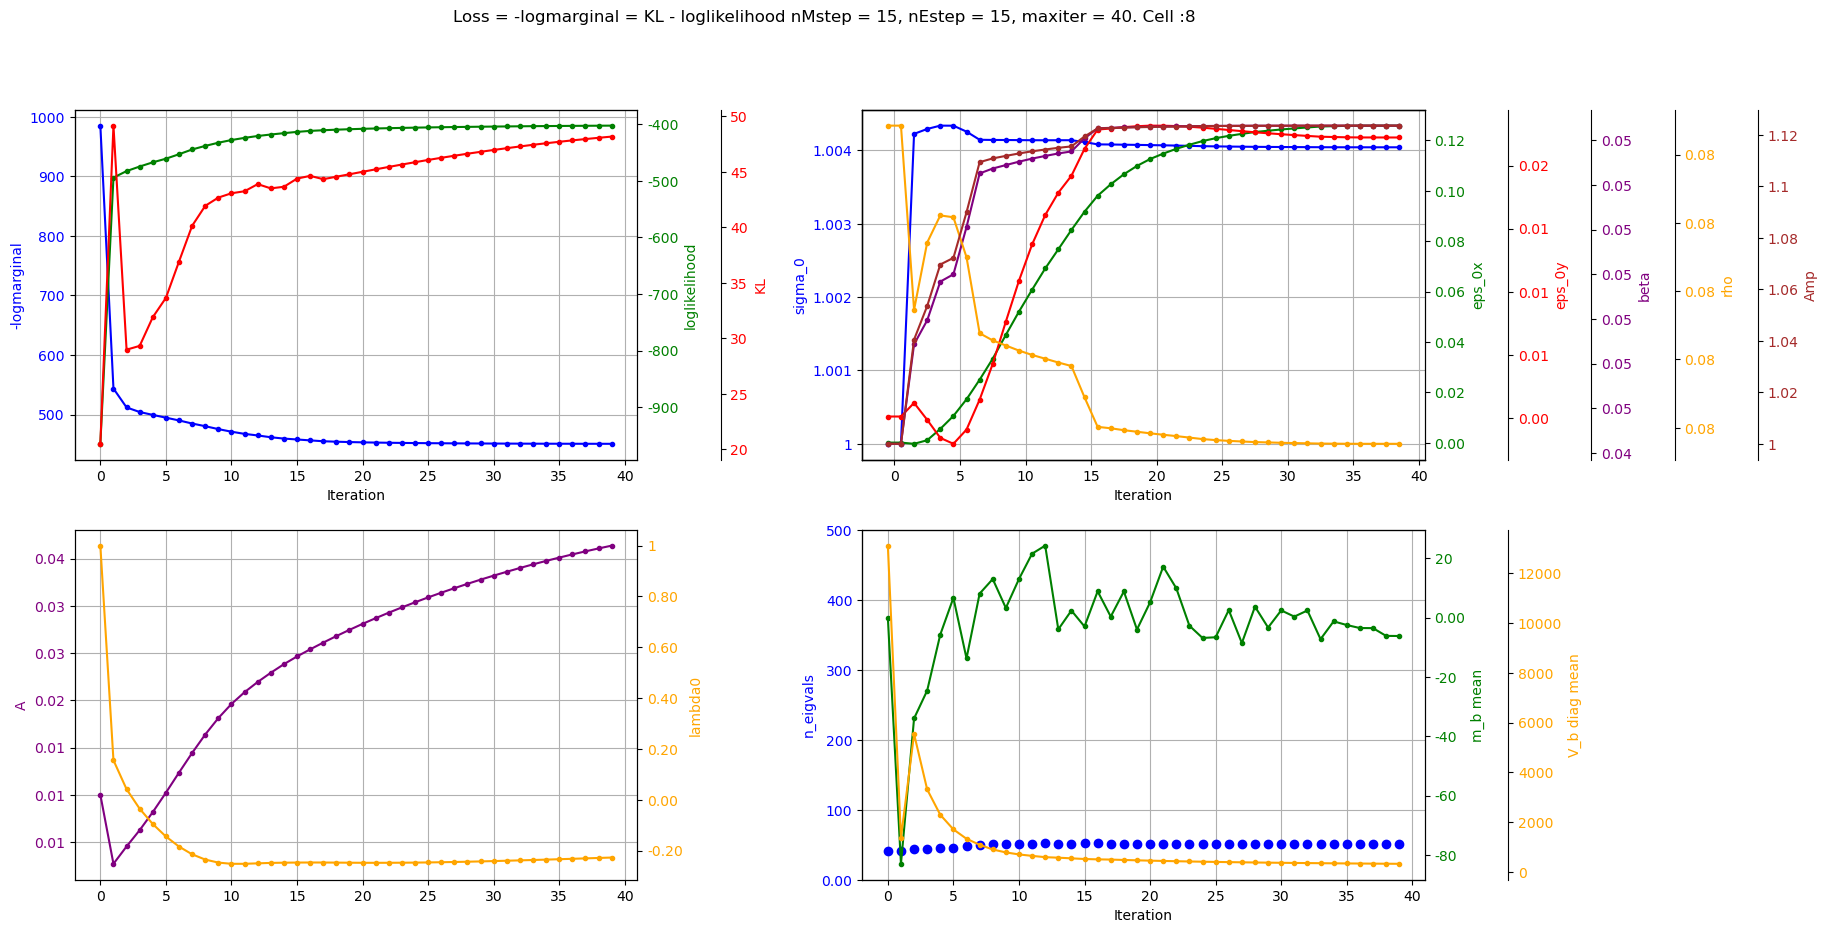

In [32]:
torch.set_grad_enabled(False)

init_model['fit_parameters']['kernfun'] = GP_utils.acosker
fit_model, err_dict = GP_utils.varGP(X_in_use, R_in_use, **init_model)

# Save the model. All of the matrices are projected in the eigenspace of big eigenvalues of K_tilde. Indicated by _b
start_model = fit_model

if err_dict['is_error']:
    print('Error in the fit')
    raise err_dict['error']

# Save the model
# GP_utils.save_model(start_model, f'models/starting_models_active_learning/cell:{cellid}_nstart:{ntrain_start}', additional_description='Starting model for active learning')

spk_count_test, spk_count_pred, r2, sigma_r2 = GP_utils.test(X_test, R_test, X_train=X, at_iteration=None, **fit_model )
# spk_count_test, spk_count_pred, r2, sigma_r2 = GP_utils.test(X_test, R_test, X_train=X, at_iteration=None, **start_model )

GP_utils.plot_loss_and_theta_notebook(fit_model, figsize=(15,10), marker='.')#ylim_logmarg=(0, 5000))


### Save or load model

In [34]:
# Save the model
# GP_utils.save_model(fit_model, Path(f'data/models'), name=f'model_cell:{cellid}', additional_description='Model started with 50 ntilde=ntrain, randomly picked images until nan in r2. Saved last model (after fit ). It gives Nan')

# Upload fit model
with open(Path(f'data/models/model_cell:{cellid}'), 'rb') as f:
    start_model = pickle.load(f)


### Active Learning with conditioned_utility_clean

This section tests the new `conditioned_utility_clean()` function which computes:
- **Conditional utility**: H(r|x_star) - E[H(r|x_star, x_i)]

Instead of the old `nd_utility()` which computes marginal utility only.

### Active Learning Loop

Run the active learning loop using `conditioned_utility_clean()` to select images.

In [68]:
from tracemalloc import start


torch.set_grad_enabled(False)

# Convert initial model to GPModel
active_model = GPModel(model_dict=start_model)
current_spikes = R_in_use.clone()

active_model.kernfun = GP_utils.acosker

# Active learning parameters
n_iterations = 50  # Number of images to add
r_cutoff = 100

# Tracking lists
utilities_track = []
r2_track = []

# Save directory for plots (script-compatible: all outputs to files)
save_dir = Path('data/optimization_comparison')
save_dir.mkdir(parents=True, exist_ok=True)
(save_dir / 'single_img_samples').mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {save_dir}")

for j in range(n_iterations):
    print(f'\n=== Iteration {j} ===')

    # 1. Get remaining images (ALL of them)
    in_use_idx = active_model.in_use_idx
    remaining_idx = all_idx_perm[~torch.isin(all_idx_perm, in_use_idx)]

    # ==========================================================================
    # 2. SELECT & OPTIMIZE using batch_utility_w_grad (RMS constraint)
    #    This efficiently computes utility for ALL remaining images and optimizes
    # ==========================================================================
    result_rms = GP_utility.batch_utility_w_grad(
        active_model,
        X,  # Full image dataset
        remaining_idx,
        max_r_cap=r_cutoff,
        max_iter=10,
        test_rms_constraint=True,
        lr=1,
        return_logf_moments=True,
        verbose=False
    )

    x_idx_best = result_rms['img_idx'].item()
    # print(f'  Selected image idx: {x_idx_best}')
    # print(f'  RMS Utility: {result_rms["U_initial"]:.4f} -> {result_rms["U_final"]:.4f}')

    # ==========================================================================
    # 3. OPTIMIZE using conditioned utility (for comparison/snapshot)
    #    This provides a different optimization approach using conditioned utility
    # ==========================================================================
    with torch.enable_grad():
        result_cond = GP_utility.optimize_with_conditioned_utility(
            model=active_model,
            imgs_train=X,
            remaining_idx=remaining_idx,
            start_img_idx=x_idx_best,
            N=1,  # Single sample for DEBUG_SINGLE_IMAGE compatibility
            lambda_samples=100,
            n_iterations=20,
            r_cutoff=r_cutoff,
            return_logf_moments=True,
            DEBUG_dict={
                'DEBUG_SINGLE_IMAGE': True,
                'DEBUG_FULL_FIELD': True,
                'verbose': False}
        )

    print(f'  Cond Utility: {result_cond["U_initial"]:.4f} -> {result_cond["U_final"]:.4f}')

    # ==========================================================================
    # 4. SAVE PLOTS (script-compatible: save to files, not shown interactively)
    # ==========================================================================

    # Single image sampling plot
    GP_utils.single_image_sampling_plot(
        result_cond,
        X,
        save_path=save_dir / 'single_img_samples' / f'iter_{j:03d}_idx_{x_idx_best}.png',
        shared_scale=True,
        initial_img=result_cond['initial_img']
    )

    # Update optimization comparison statistics
    GP_utils.update_optimization_comparison(
        result_dict={'RMS': result_rms, 'cond_utility': result_cond},
        imgs_train=X,
        n_images=len(in_use_idx) + 1,  # Current number of images after adding this one
        save_dir=save_dir,
        model=active_model
    )

    # Track results
    utilities_track.append({
        'rms_U_initial': result_rms['U_initial'],
        'rms_U_final': result_rms['U_final'],
        'cond_U_initial': result_cond['U_initial'],
        'cond_U_final': result_cond['U_final'],
        'img_idx': x_idx_best,
    })

    # ==========================================================================
    # 5. UPDATE MODEL WITH ORIGINAL IMAGE AND RESPONSE
    #    IMPORTANT: We use the ORIGINAL image for training, NOT the optimized one.
    #    The optimization above is just a snapshot of what WOULD happen if we
    #    optimized - but since we have real neural responses to original images,
    #    we must train on originals.
    # ==========================================================================
    new_spike = R[x_idx_best]
    current_spikes = torch.cat((current_spikes, new_spike[None]))

    active_model = GP_utils.generate_new_active_model(
        current_model=active_model,
        x_idx_chosen=torch.tensor([x_idx_best], device=device),
        img_train=X,
        new_spike_counts=current_spikes
    )

    # ==========================================================================
    # 6. FIT MODEL (on original images)
    # ==========================================================================
    model_dict, err_dict = GP_utils.varGP(
        X[active_model.in_use_idx],
        current_spikes,
        **active_model.to_dict(),
        verbose=False
    )
    active_model = GPModel(model_dict=model_dict)

    if err_dict['is_error']:
        print(f'  Error in fit: {err_dict["error"]}')
        if not isinstance(err_dict['error'], GP_utils.LossStagnationError):
            raise err_dict['error']


    # ==========================================================================
    # 7. EVALUATE ON TEST SET
    # ==========================================================================
    # _, _, r2, _ = GP_utils.test(X_test, R_test, at_iteration=None, **active_model.to_dict())
    # r2_track.append(r2.item())
    # print(f'  R^2: {r2.item():.4f}')

print('\n' + '='*50)
print('Active learning loop completed!')
print(f'Final R^2: {r2_track[-1]:.4f}')
print(f'Plots saved to: {save_dir}')

Plots will be saved to: data/optimization_comparison

=== Iteration 0 ===

=== RMS-Constrained Optimization (Slim Version) ===
Running L-BFGS with max_iter=10...
 DEBUG MODEL FULL FIELD MODE ACTIVE 
   Gray value (starting): 0.0384
   White value (sampled): 2.4780


KeyboardInterrupt: 